# Numeric Integration for DAEs
**Prepared by:** Prof. Alexander Dowling, Myia Dickens (mdicken2@nd.edu,2023)

This notebook is the computational companion to Lectures 5--7. It connects error and stability experiments for ODE integrators to index-1 DAE integration, then prepares for direct collocation in `Pyomo.dae`.

In [1]:
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    # Do not need casadi for this notebook
    #!pip install casadi
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()


import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt

## Single-Step Runge-Kutta Methods

* Chapter 9 in [Biegler (2010)](https://epubs.siam.org/doi/book/10.1137/1.9780898719383)
* Chapter 17 in [McClarren (2018)](https://www.sciencedirect.com/book/9780128122532/computational-nuclear-engineering-and-radiological-science-using-python)

### General Form: Index 0 DAE

Consider the ODE system:

\begin{equation}
\dot{z} = f(t,z), \quad z(t_0) = z_0
\end{equation}

where $z(t)$ are the differential variables and $f(t,z)$ is a (nonlinear) continuous function.

The general Runge-Kutta formula is:
\begin{align}
z_{i+1} &= z_{i} + h_i \sum_{k=1}^{n_s} b_k f(t_i + c_k h_i, \hat{z}_k) \\
    \hat{z}_k &= z_i + h_i \sum_{j=1}^{n_{rk}} a_{k,j} f(t_i + c_j h_i, \hat{z}_j), \quad k=1,...,n_s 
\end{align}

where
* $z_i$ are the differential variables at the **start** of **step** $i$ (time $t_i$)
* $z_{i+1}$ are the differential variables at the **end** of **step** $i$ (time $t_{i+1}$)
* $\hat{z}_k$ are differential variables for **intermediate stage** $k$
* $h_i$ is the size for step $i$ such that $t_{i+1} = t_i + h_i$
* $n_s$ is the number of stages
* $n_{rk}$ is the number of $f(\cdot)$ evaluations to calculate intermediate $k$
* $a_{k,j}$ are coefficients, together known as the *Runge-Kutta matrix*
* $b_k$ are coefficients, known as the *weights*
* $c_k$ are coefficients, known as the *nodes*

$h_i$ is selected based on error tolerances

The choice for $A$, $b$ and $c$ selects the specific method in the *Runge-Kutta family*. These coefficients are often specified in a [Butcher block](https://en.wikipedia.org/wiki/Runge%E2%80%93Kutta_methods#Explicit_Runge) (or Butcher tableau).

A Runge-Kutta method is called [**consistent**](https://en.wikiversity.org/wiki/Numerical_Analysis/stability_of_RK_methods) if:
\begin{equation}
\sum_{k=1}^{n_s} b_k = 1 \quad \mathrm{and} \quad \sum_{j=1}^{n_s} a_{k,j} = c_k
\end{equation}

### Explicit (Forward) Euler

Consider one of the simplest Runge-Kutta methods:

$$z_{i+1} = z_{i} + h_i~f(t_i, z_i)$$

What are $A$, $b$ and $c$ in the general formula?

$n_s = 1$. This is only a single stage. Thus we only need to determine $c_1$, $b_1$, and $n_{r1}$

Moreover, $\hat{z}_1 = z_i$ because $f(\cdot)$ is only evaluated at $t_i$ and $z_i$. This implies:
* $n_{r1} = 0$
* $c_1 = 0$
* $b_1 = 1$
* $A$ is empty because $n_{r1} = 0$

The implementation is very straightforward (see below). We can calculate $z_{i+1}$ with a single line!

In [2]:
def create_steps(tstart, tend, dt):
    n = int(np.ceil((tend - tstart) / dt))
    return dt * np.ones(n)


def explicit_euler(f, h, z0):
    """
    Arguments:
        f: function that returns rhs of ODE
        h: list of step sizes
        z0: initial conditions

    Returns:
        t: list of time steps. t[0] is 0.0 by default
        z: list of differential variable values
    """

    # Number of timesteps
    nT = len(h) + 1

    t = np.zeros(nT)

    # Number of states
    nZ = len(z0)
    Z = np.zeros((nT, nZ))

    # Copy initial states
    Z[0, :] = z0

    for i in range(1, nT):

        i_ = i - 1

        # Advance time
        t[i] = t[i_] + h[i_]

        # Explicit Euler formula
        Z[i, :] = Z[i_, :] + h[i_] * f(t[i_], Z[i_, :])

    return t, Z

### Implicit (Backward) Euler

Consider another simple Runge-Kutta method:

$$z_{i+1} = z_{i} + h_i~f(t_{i+1}, z_{i+1})$$

What are $A$, $b$ and $c$ to express using the general formula?

$n_s = 1$. This is only a single stage. Moreover, $\hat{z}_1 = z_{i+1}$ because $f(\cdot)$ is evaluated at $t_{i+1}$ and $z_{i+1}$. This implies:
* $b_1 = 1$
* $c_1 = 1$

Moreover, $z_{i+1} = z_{i} + h_i~f(t_{i+1}, z_{i+1})$ implies $\hat{z}_1 = z_i + h_i f(t_{i+1}, \hat{z}_1)$. Thus:
* $a_{1,1} = 1$

Notice that the formula for $z_{i+1}$ is implicit. We need to solve a (nonlinear) system of equations to calculate the step.

In [3]:
def implicit_euler(f, h, z0):
    """
    Arguments:
        f: function that returns rhs of ODE
        h: list of step sizes
        z0: initial conditions

    Returns:
        t: list of time steps. t[0] is 0.0 by default
        z: list of differential variable values
    """

    # Number of timesteps
    nT = len(h) + 1

    t = np.zeros(nT)

    # Number of states
    nZ = len(z0)
    Z = np.zeros((nT, nZ))

    # Copy initial states
    Z[0, :] = z0

    for i in range(1, nT):

        i_ = i - 1

        # Advance time
        t[i] = t[i_] + h[i_]

        ## Implicit Runge-Kutta formula.
        ## Need to solve nonlinear system of equations.

        # Use Explicit Euler to calculate initial guess
        Z[i, :] = Z[i_, :] + h[i_] * f(t[i_], Z[i_, :])

        # Solve nonlinear equation
        implicit = lambda z: Z[i_, :] + h[i_] * f(t[i], z) - z
        Z[i, :] = opt.fsolve(implicit, Z[i, :])

    return t, Z

## Key Differences

| Explicit Methods 	| Implicit Methods 	|
|:---:	|:---:	|
| + Easy to Program  	| - Requires converging system of nonlinear equations 	|
| - Stability regions are often bounded, so stability can restrict $h_i$ 	| + Stability regions are often larger or unbounded, but still depend on the method and problem 	|

### Comparison

Let's test this on a simple problem:

\begin{equation}
\dot{z}(t) = -\lambda z(t), \qquad z_0 = 1.
\end{equation}

The solution to this problem is 
\begin{equation}
z(t) = e^{-\lambda t}.
\end{equation}

For simplicity, let's numerically analyze $\lambda = 1$.

![Forward and backward Euler on $\dot z = -z$ at $h=1.0$ and $h=2.5$: below the bound $h<2/\lambda$ both methods decay; above it forward Euler oscillates and grows while backward Euler does not.](../../media/figures/euler-stability.png)

The stability contrast in one picture, rendered from `figures/plots/euler-stability.py`.
This is the **same image printed in the course pack**, so the handout and the website
cannot drift apart.

Run the two cells below to reproduce each panel yourself and to change `dt`.


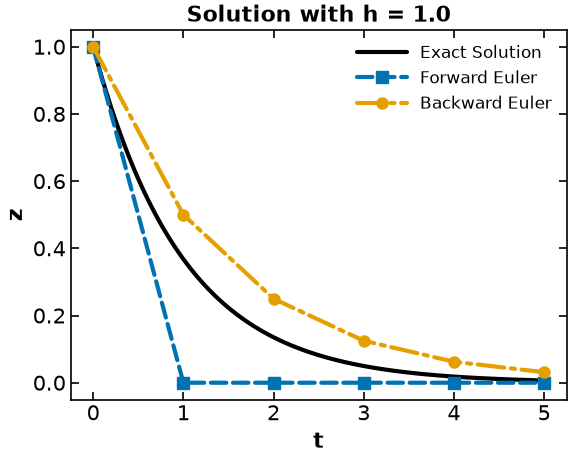

In [4]:
rhs = lambda t, z: -z
sln = lambda t: np.exp(-t)

dt = 1.0
h = create_steps(0.0, 5.0, dt)

z0 = [1]

te, Ze = explicit_euler(rhs, h, z0)
ti, Zi = implicit_euler(rhs, h, z0)

plt.figure()

# Use 101 points for exact to make it smooth
texact = np.linspace(0.0, np.sum(h), 101)

# Plot solutions
plt.plot(texact, sln(texact), label="Exact Solution")
plt.plot(te, Ze, marker="s", label="Forward Euler")
plt.plot(ti, Zi, marker="o", label="Backward Euler")
plt.xlabel("t")
plt.ylabel("z")
plt.legend()
plt.title("Solution with h = " + str(dt))
plt.show()

### Stability

Keeping $\lambda = 1$, are there any limits on step size?



/var/folders/3w/vr4xmyqs451dg23xk88pqcg00000gq/T/ipykernel_47280/1577139293.py:40: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Z[i, :] = opt.fsolve(implicit, Z[i, :])


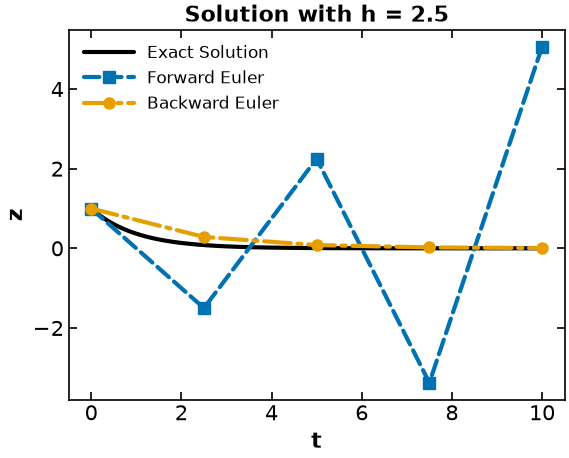

In [5]:
dt = 2.5
h = create_steps(0.0, 10.0, dt)

z0 = [1]

te, Ze = explicit_euler(rhs, h, z0)
ti, Zi = implicit_euler(rhs, h, z0)

plt.figure()

# Use 101 points for exact to make it smooth
texact = np.linspace(0.0, np.sum(h), 101)

# Plot solutions
plt.plot(texact, sln(texact), label="Exact Solution")
plt.plot(te, Ze, marker="s", label="Forward Euler")
plt.plot(ti, Zi, marker="o", label="Backward Euler")
plt.xlabel("t")
plt.ylabel("z")
plt.legend()
plt.title("Solution with h = " + str(dt))
plt.show()

**Key observation:** forward (explicit) Euler becomes unstable with large steps whereas backward (implicit) Euler is stable.

The Lecture 6 handout derives the growth factors and then generalizes them to absolute-stability regions.

**Key results** (for this specific test problem):
* Forward Euler is stable for this problem when $h\lambda \leq 2$ and non-oscillatory when $h\lambda \leq 1$.
* Backward Euler is stable and non-oscillatory for every $h > 0$ when $\lambda > 0$.
* Crank--Nicolson is stable for every $h > 0$, but oscillates when $h\lambda > 2$.
* Similar analysis and concepts extend to Runge-Kutta methods.

![Regions of absolute stability in the complex h-lambda plane: forward Euler is a bounded disc, backward Euler is the exterior of a disc, Crank-Nicolson is exactly the left half-plane.](../../media/figures/stability-regions.png)

Why the step-size limit exists, in one picture. Rendered from
`figures/plots/stability-regions.py`; the **same image printed in the course pack**.

The shaded set is where the method does not amplify. A method is **A-stable** when that set
covers the entire left half-plane (Ascher & Petzold, p. 56). Forward Euler's region is
*bounded*, so it never can be -- hence $h < 2/\lambda$. Backward Euler and Crank-Nicolson
both are.


### Error Analysis

How does our choice in step size $h$ impact the error of these numerical techniques?



![Global error vs step size for forward and backward Euler on $\dot z=-z$, log-log axes; both slopes are 1.](../../media/figures/euler-error-order.png)

The order of accuracy, **measured** rather than asserted. Rendered from
`figures/plots/euler-error-order.py`. This is the **same image printed in the course pack**,
so the handout and the website cannot drift apart.

Both slopes are **1**, not 2. Forward and backward Euler each commit $O(h^2)$ on a *single
step*, but a fixed interval takes $N \propto 1/h$ steps, so the *global* error is $O(h)$ --
one order is paid away to the step count. Read the slope, not the per-step order.

Run the cell below to reproduce it yourself and to change the step list.


/var/folders/3w/vr4xmyqs451dg23xk88pqcg00000gq/T/ipykernel_47280/1577139293.py:40: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  Z[i, :] = opt.fsolve(implicit, Z[i, :])


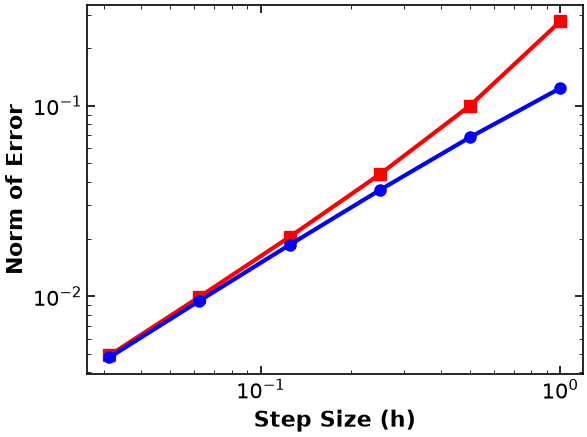

Slope for Forward Euler: 1.0220608473216777
Slope for Backward Euler: 0.9874086317220971


In [6]:
Delta_t = np.array([1.0, 0.5, 0.25, 0.125, 0.0625, 0.0625 / 2])
t_final = 2
error_forward = np.zeros(Delta_t.size)
error_backward = np.zeros(Delta_t.size)

for i in range(0, len(Delta_t)):

    # create steps
    h = create_steps(0.0, t_final, Delta_t[i])

    # solve
    t, ze = explicit_euler(rhs, h, z0)
    t, zi = implicit_euler(rhs, h, z0)
    zsln = np.exp(-t)

    n = len(t) - 1

    # Calculate error
    error_forward[i] = np.linalg.norm(ze[:, 0] - zsln) / np.sqrt(n)
    error_backward[i] = np.linalg.norm(zi[:, 0] - zsln) / np.sqrt(n)


plt.loglog(Delta_t, error_forward, "s-", color="red", label="Forward Euler")
plt.loglog(Delta_t, error_backward, "o-", color="blue", label="Backward Euler")

# slope = (np.log(error[-1]) - np.log(error[-2]))/(np.log(Delta_t[-1])- np.log(Delta_t[-2]))
# plt.title("Slope of Error is " + str(slope))
plt.xlabel("Step Size (h)")
plt.ylabel("Norm of Error")
plt.show()

# Calculate slope
calc_slope = lambda error: (np.log(error[-1]) - np.log(error[-2])) / (
    np.log(Delta_t[-1]) - np.log(Delta_t[-2])
)

print("Slope for Forward Euler: " + str(calc_slope(error_forward)))
print("Slope for Backward Euler: " + str(calc_slope(error_backward)))

Both Euler methods are first order in $\Delta t$: halving $\Delta t$ approximately halves the global error. Here we measure the error with the root-mean-square norm
$$\mathrm{Error} = \frac{1}{\sqrt{N}}\sqrt{\sum_{n=1}^{N} \left(y^n_\mathrm{approx} - y^n_\mathrm{exact}\right)^2},$$
where $N$ is the number of steps the ODE is solved over.

**Key Results**:
* Implicit and Explicit Euler have $O(h^2)$ local error and $O(h)$ global error.

## Extending Numeric Integration to Index-1 DAEs

Consider semi-explicit DAEs:
$$\begin{aligned}
\dot{z} = f(t,z,y), \quad g(z,y) = 0, \quad z(t_0) = z_0
\end{aligned}$$

Runge-Kutta methods are easy to extend.

$$\begin{aligned}
z_{i+1} &= z_{i} + h_i \sum_{k=1}^{n_s} b_k f(t_i + c_k h_i, \hat{z}_k, \hat{y}_k) \\
    \hat{z}_k &= z_i + h_i \sum_{j=1}^{n_{rk}} a_{k,j} f(t_i + c_j h_i, \hat{z}_j, \hat{y}_j), \quad k=1,...,n_s \\
    0 &= g(\hat{z}_k, \hat{y}_k), \quad k=1,...,n_s
\end{aligned}$$

Backward differentiation formulas (BDFs) also extend to index-1 DAEs. Backward Euler is the one-step, first-order member of this family.

$$\begin{aligned}
  z_{i+1} &= \sum_{j=1}^{n_s} \alpha_j z_{i-j+1} + \beta_0 hf(z_{i+1},y_{i+1})\\
  0 &= g(z_{i+1},y_{i+1})
\end{aligned}$$

At each BDF step, solve the coupled equations for $(z_{i+1},y_{i+1})$ with Newton's method. Using the conventional row-by-variable Jacobian and the residual $z_{i+1}-\sum_j \alpha_j z_{i-j+1}-\beta_0 h f(z_{i+1},y_{i+1})=0$, the Jacobian is:

$$\begin{aligned}
J(z_{i+1},y_{i+1}) &= 
\begin{bmatrix}
I - h\beta_0\frac{\partial f}{\partial z}
& -h\beta_0\frac{\partial f}{\partial y} \\
\frac{\partial g}{\partial z} & \frac{\partial g}{\partial y}
\end{bmatrix}
\end{aligned}$$

This follows Biegler (2010), equations (9.18)--(9.19), pp. 259--260, with two corrections made explicit: derivatives here use the course's row-by-variable convention, and the upper-right block has a minus sign when the first residual is written in the form above. The printed equation (9.19) combines the opposite sign in that block with $I-h\beta_0 f_z$; direct differentiation shows those signs cannot belong to the same residual, and the published errata do not list the issue.

**Key Results**. For an index-1 DAE, implicit RK and BDF extensions generally retain ODE-like order and stability properties, subject to method-specific order-reduction and stability limitations.

**Discussion:** Why are *implicit* methods usually preferred for index-1 DAE systems?

### Backward Euler transcription of an ODE-constrained optimization problem

Reference: Bynum, Hackebeil, Hart, Laird, Nicholson, Siirola, Watson & Woodruff,
**Pyomo — Optimization Modeling in Python**, 3rd ed., Springer (2021), §12.1, p. 181,
equations (12.1)–(12.6). (Earlier versions of this notebook cited "Hart, 2010", which is
the *1st* edition — a different book with different pagination.)

The example below is an ODE model with a path inequality, not a DAE. It shows how backward Euler exposes time-indexed states, controls, and constraints to an optimization solver.

Consider the following optimal control problem


\begin{align} \min_{u(t)} \quad & x_3(t_f) \\
\mathrm{s.t.} \quad & \dot{x}_1 = x_2 \\
& \dot{x}_2 = -x_2 + u(t)  \\
& \dot{x}_3 = x_1^2 + x_2^2 + 0.005 \cdot u^2 \\
& x_2 - 8 \cdot (t-0.5)^2 + 0.5 \leq 0 \\
& x_1(0) = 0, x_2(0) = -1, x_3(0) = 0, t_f = 1 
\end{align}

*Discussion*: What variable is the problem attempting to minimize? What variable is being optimized? What types of equations are there?



```{dropdown} Click here to expand

Manipulated variables: $u(t)$

Objective: $x_3(t_f)$

3 differential equations in the constraints and a path constraint, which is an inequality constraint restricting a variable. 

The path constraint directly impacts $x_2$.


```

In [7]:
import pyomo.environ as pyo
import pyomo.dae as dae

```{note}
**No Pyomo units in this model, and two separate reasons why.**

The dynamic optimization notebooks in this section declare `units=` on every `Var` and
`Param` and check them with `assert_units_consistent` before discretizing -- see
[](./units_and_pyomo_dae.md). This model is an honest exception on both counts.

1. **The states are abstract.** $x_1$, $x_2$, $x_3$ come from the Pyomo book's
   §12.1 test problem. They have no physical referent, so any units we assigned would
   be invented. Inventing units is worse than omitting them: it produces a check that
   looks meaningful and is not.

2. **The path constraint indexes time directly.** Look at the rule:

   ```python
   def _con(m, t):
       return m.x2[t] - 8 * (t - 0.5) ** 2 + 0.5 <= 0
   ```

   That `t` is a **bare Python float** -- the raw `ContinuousSet` index that Pyomo
   passed into the rule. It is not a Pyomo object and it carries no units, so there is
   nothing to attach units *to*. This is the cleanest illustration in the course of
   [Pyomo issue #1790](https://github.com/Pyomo/pyomo/issues/1790) (*add units support
   to `ContinuousSet`/`Pyomo.dae`*, still open): a `ContinuousSet` cannot hold units,
   which is also why a units-correct `Pyomo.dae` model passes
   `assert_units_consistent` **before** discretization and fails after it.

   When a model *is* physical and needs a time-dependent reference trajectory, the
   workaround is to have the helper return a bare number and multiply by the intended
   units at the call site. [](./hot_air_balloon.ipynb) does exactly that.
```


In [8]:
def create_dynamic_optimization_model():

    # Create model
    m = pyo.ConcreteModel()

    # Declare time set
    m.tf = pyo.Param(initialize=1)  # final time
    m.t = dae.ContinuousSet(bounds=(0, m.tf))

    # Declare constraint and input variables
    m.u = pyo.Var(m.t, initialize=0)
    m.x1 = pyo.Var(m.t)
    m.x2 = pyo.Var(m.t)
    m.x3 = pyo.Var(m.t)

    # Declare differential variables
    m.dx1 = dae.DerivativeVar(m.x1, wrt=m.t)
    m.dx2 = dae.DerivativeVar(m.x2, wrt=m.t)
    m.dx3 = dae.DerivativeVar(m.x3)

    # Declare differential equations
    @m.Constraint(m.t)
    def x1dotcon(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dx1[t] == m.x2[t]

    @m.Constraint(m.t)
    def x2dotcon(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dx2[t] == -m.x2[t] + m.u[t]

    @m.Constraint(m.t)
    def x3dotcon(m, t):
        if t == m.t.first():
            return pyo.Constraint.Skip
        return m.dx3[t] == m.x1[t] ** 2 + m.x2[t] ** 2 + 0.005 * m.u[t] ** 2

    # Declare inequality constraints
    @m.Constraint(m.t)
    def con(m, t):
        return m.x2[t] - 8 * (t - 0.5) ** 2 + 0.5 <= 0

    # Declare the initial conditions
    @m.Constraint()
    def init_x1(m):
        return m.x1[0] == 0

    @m.Constraint()
    def init_x2(m):
        return m.x2[0] == -1

    @m.Constraint()
    def init_x3(m):
        return m.x3[0] == 0

    # Declare Objective function
    m.obj = pyo.Objective(expr=m.x3[m.tf])

    return m


# Discretize and solve using backward Euler
def solve_with_backward_euler(m):
    """
    Arguments:
      m: Pyomo.DAE dynamic optimization model
    New Elements:
      nfe = number for finite elements - specifies the number of discretization points to be used
    Purpose:
      Discretizes the ODE constraints with backward Euler and solves the NLP
    """

    discretizer = pyo.TransformationFactory("dae.finite_difference")
    discretizer.apply_to(m, nfe=20, wrt=m.t, scheme="BACKWARD")

    solver = pyo.SolverFactory("ipopt")
    results = solver.solve(m, tee=True)
    assert pyo.check_optimal_termination(results), (
        f"Solve failed: status={results.solver.status}, "
        f"termination={results.solver.termination_condition}"
    )


# Plot the results
def plotter(subplot, x, *y, **kwds):
    plt.subplot(subplot)
    # Color AND linestyle, so the figure survives a black-and-white printout.
    linestyles = ["-", "--", "-.", ":"]
    for i, _y in enumerate(y):
        plt.plot(
            list(x),
            [pyo.value(_y[t]) for t in x],
            color="brgcmk"[i % 6],
            linestyle=linestyles[i % 4],
        )
        if kwds.get("points", False):
            plt.plot(list(x), [pyo.value(_y[t]) for t in x], "o")
    plt.title(kwds.get("title", ""), fontsize=16, fontweight="bold")
    plt.tick_params(direction="in", labelsize=15)
    plt.legend(tuple(_y.name for _y in y))
    plt.xlabel(x.name, fontsize=16, fontweight="bold")


def plot_results(m):
    plotter(121, m.t, m.x1, m.x2, title="Differential Variables")
    plotter(122, m.t, m.u, title="Control Variable", points=True)
    plt.show()


# Create model
model = create_dynamic_optimization_model()

In [9]:
# Solve the discretized dynamic optimization problem
results = solve_with_backward_euler(model)

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:      363
Number of nonzeros in inequality constraint Jacobian.:       21
Number of nonzeros in Lagrangian Hessian.............:       60

Total number of variables............................:      143
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:      123
Total number

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10  1.4796952e-01 6.90e-13 2.51e-14  -8.6 1.15e-05    -  1.00e+00 1.00e+00h  1

Number of Iterations....: 10

                                   (scaled)                 (unscaled)
Objective...............:   1.4796951825372692e-01    1.4796951825372692e-01
Dual infeasibility......:   2.5063284780912909e-14    2.5063284780912909e-14
Constraint violation....:   6.9008687653138168e-13    6.9008687653138168e-13
Variable bound violation:   0.0000000000000000e+00    0.0000000000000000e+00
Complementarity.........:   2.5060342008003911e-09    2.5060342008003911e-09
Overall NLP error.......:   2.5060342008003911e-09    2.5060342008003911e-09


Number of objective function evaluations             = 11
Number of objective gradient evaluations             = 11
Number of equality constraint evaluations            = 11
Number of inequality constraint evaluations          = 11
Number of equality constraint Jacobian e

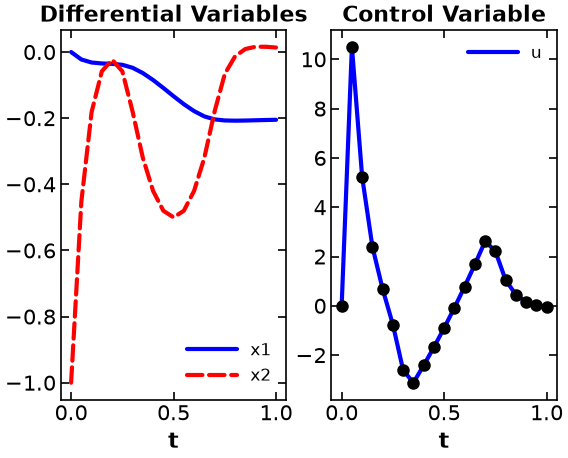

In [10]:
# Plot solution
plot_results(model)

## Stiff chemical-reaction example

Consider consecutive first-order reactions $A \rightarrow B \rightarrow C$ with $k_1=1000$ and $k_2=1$:

\begin{equation}
\dot{c} = \begin{bmatrix} -k_1 & 0 & 0 \\ k_1 & -k_2 & 0 \\ 0 & k_2 & 0\end{bmatrix} c,
\qquad c(0) = [1, 0, 0]^T .
\end{equation}

The Jacobian eigenvalues are $-k_1$, $-k_2$ and $0$, so the **stiffness ratio is $k_1/k_2 = 1000$**: $A$ disappears in about $1/k_1 = 1$ ms while $B$ is still converting a thousand times more slowly. We compare one explicit adaptive method (`RK45`) with three methods designed for, or able to detect, stiffness (`Radau`, `BDF`, `LSODA`).

Use the same tolerances for every method, and **compare solver work through accepted steps and right-hand-side evaluations rather than wall time**, which varies substantially across computers and Colab sessions.

In [11]:
# ---------- MODEL ----------------------------------------------------------
# Consecutive first-order reactions  A --k1--> B --k2--> C  with k1 = 1000 and
# k2 = 1. The Jacobian's eigenvalues are -k1, -k2 and 0, so the stiffness ratio
# is k1/k2 = 1000: A disappears on a timescale of 1/k1 = 1 ms while B is still
# converting on a timescale of 1/k2 = 1 s.
#
# The system is LINEAR, so the Jacobian is constant and exact. That is
# deliberate: Radau and BDF are handed the analytic Jacobian, which removes
# "how good is the finite-difference Jacobian" as an explanation for the work
# counts below. It also gives an analytic solution to measure error against.
from scipy.integrate import solve_ivp

k1, k2 = 1000.0, 1.0

reaction_jacobian = np.array([[-k1, 0.0, 0.0],
                              [k1, -k2, 0.0],
                              [0.0, k2, 0.0]])


def reaction_rhs(t, concentration):
    """d[A, B, C]/dt for the consecutive first-order reactions."""
    return reaction_jacobian @ concentration


def reaction_exact(t):
    """Analytic solution from [A, B, C](0) = [1, 0, 0]; rows are A, B, C.

    A = e^{-k1 t},  B = k1/(k1 - k2) (e^{-k2 t} - e^{-k1 t}),  C = 1 - A - B.
    Used as the accuracy reference, so "cheap" cannot be confused with "loose".
    """
    t = np.asarray(t, dtype=float)
    a = np.exp(-k1 * t)
    b = k1 / (k1 - k2) * (np.exp(-k2 * t) - np.exp(-k1 * t))
    return np.vstack([a, b, 1.0 - a - b])

In [12]:
# ---------- SOLVE + EXTRACT ------------------------------------------------
# Everything below this cell reads `results` and nothing else. The archive
# figures/results/stiff-solver-comparison.json stores the DATA -- the accepted
# step sequence, the work counters and the measured error for each method -- so
# the figure can be restyled later without re-integrating. See figures/README.md
# and figures/render_from_notebook.py for the cell contract.
#
# ⚠ EVERY METHOD GETS THE SAME TOLERANCES. Comparing work at different
# tolerances measures nothing, so rtol/atol are fixed here and the achieved
# error is measured afterwards to confirm the four answers really are
# comparable.
#
# ⚠ WORK, NOT WALL TIME. Prof. Dowling's standing instruction for this
# comparison: count right-hand-side evaluations and accepted steps, which are
# properties of the method and the problem, not of the laptop or the Colab VM
# the notebook happens to run on.

t_final = 5.0
rtol, atol = 1e-7, 1e-10
transient_end = 0.5   # after this, A is gone and only the slow B -> C remains

# Dormand-Prince's real-axis absolute-stability boundary is h|lambda| ~ 3.3.
# With lambda = -k1 that caps the explicit step at ~3.3/k1 no matter how smooth
# the solution has become -- which is the whole argument of this section.
explicit_step_ceiling = 3.3 / k1

method_kind = {"RK45": "explicit", "Radau": "implicit",
               "BDF": "implicit", "LSODA": "switching"}

t_check = np.linspace(0.0, t_final, 2001)
exact_check = reaction_exact(t_check)

methods_out = []
solutions = {}   # kept for the concentration-profile diagnostic below
for method in ("RK45", "Radau", "BDF", "LSODA"):
    options = {"jac": reaction_jacobian} if method in ("Radau", "BDF") else {}
    solution = solve_ivp(
        reaction_rhs, (0.0, t_final), [1.0, 0.0, 0.0], method=method,
        rtol=rtol, atol=atol, dense_output=True, **options
    )

    solutions[method] = solution

    assert solution.success, f"{method} failed: {solution.message}"
    assert np.isclose(solution.t[-1], t_final), f"{method} stopped early"
    profile = solution.sol(t_check)
    mass_error = float(np.max(np.abs(profile.sum(axis=0) - 1.0)))
    assert mass_error < 1e-8, f"{method} violated A + B + C conservation"

    h = np.diff(solution.t)
    slow = solution.t[:-1] > transient_end
    methods_out.append({
        "key": method,
        "label": method,
        "kind": method_kind[method],
        "nfev": int(solution.nfev),
        "njev": int(getattr(solution, "njev", 0)),
        "nlu": int(getattr(solution, "nlu", 0)),
        "n_steps": int(h.size),
        "max_error": float(np.max(np.abs(profile - exact_check))),
        "mass_error": mass_error,
        # The step actually taken once the fast transient is over. This is the
        # number the figure is about: the stiff solvers are free here and the
        # explicit one is not.
        "h_slow": float(np.median(h[slow])),
        "h_min": float(h.min()),
        "h_max": float(h.max()),
        # Step START times, so t_step[i] is where step h[i] was taken from.
        "t_step": [float(v) for v in solution.t[:-1]],
        "h": [float(v) for v in h],
    })

results = {
    "t_final": t_final,
    "rtol": rtol,
    "atol": atol,
    "k1": k1,
    "k2": k2,
    "transient_end": transient_end,
    "explicit_step_ceiling": explicit_step_ceiling,
    "methods": methods_out,
}

print(f"{'method':<8}{'nfev':>8}{'steps':>8}{'nlu':>7}{'h (slow)':>12}{'max error':>12}")
for m in results["methods"]:
    print(f"{m['key']:<8}{m['nfev']:>8d}{m['n_steps']:>8d}{m['nlu']:>7d}"
          f"{m['h_slow']:>12.2e}{m['max_error']:>12.2e}")

helper.save_results(
    "stiff-solver-comparison",
    results,
    notebook="notebooks/3-dev/DAE_numeric_integration.ipynb",
    source_tag="handout:stiff-reaction",
    description=(
        "Work and step size for SciPy's RK45, Radau, BDF and LSODA on the stiff "
        "consecutive-reaction model A -> B -> C (k1 = 1000, k2 = 1) over "
        "t in [0, 5] at rtol 1e-7 / atol 1e-10. The explicit method is held at "
        "the absolute-stability ceiling h ~ 3.3/k1 long after the fast transient "
        "has died, and pays for it in right-hand-side evaluations; the three "
        "stiff-capable methods take steps roughly twenty times larger and reach "
        "the same accuracy."
    ),
    solver="scipy.integrate.solve_ivp",
)

method      nfev   steps    nlu    h (slow)   max error
RK45       11012    1582      0    3.25e-03    3.91e-09
Radau       1926     274     66    5.64e-02    6.67e-09
BDF          556     277     52    7.86e-02    9.33e-08
LSODA        484     236      9    7.26e-02    8.64e-08


[helper] wrote figures/results/stiff-solver-comparison.json


[helper] wrote media/figures/stiff-solver-comparison.png and .pdf


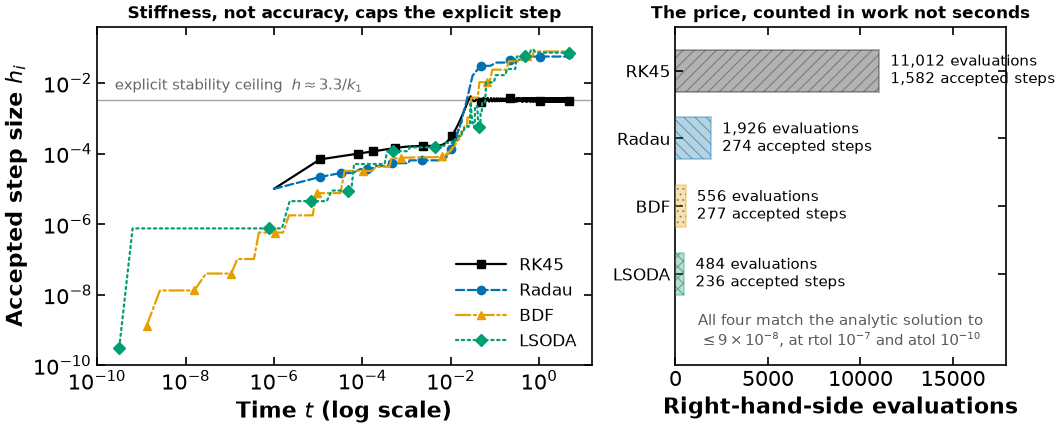

In [13]:
# The PLOTTING function: it takes the extracted step sequences and work
# counters, not a solver object.
#
# This cell is tagged `figure:stiff-solver-comparison`, which makes it the
# single source of the figure the Lecture 6 handout prints.
# figures/render_from_notebook.py re-runs exactly this cell against the archived
# JSON when the house style changes, so there is no second copy of the plotting
# code. That driver binds `np`, `plt` and `helper` for the cell, so it imports
# nothing.


def plot_stiff_solver_comparison(results):
    """Why a stiff problem needs a stiff solver, in step sizes and in work.

    LEFT PANEL -- the mechanism. Accepted step size against time. Once the fast
    transient is over (t > 0.005 or so) the solution is a smooth exponential
    decay and accuracy alone would allow a large step. Radau, BDF and LSODA
    take one. RK45 cannot: its step is pinned flat at the absolute-stability
    ceiling h ~ 3.3/k1 by the *fast* eigenvalue, which is still -1000 even
    though the mode it belongs to died long ago. That flat line is the figure.

    RIGHT PANEL -- the price. Right-hand-side evaluations, which is what
    Prof. Dowling asks students to compare instead of laptop timings: a count
    is a property of the method and the problem, a timing is a property of the
    machine. The accepted-step count is printed on each bar because the two say
    slightly different things -- RK45 is ~6x the steps but ~20x the
    evaluations, since each RK45 step costs six f-evaluations while a BDF step
    usually costs one or two.

    LOG X ON THE LEFT. The interesting behaviour spans t = 1e-6 to t = 5 --
    nine decades of step size across six decades of time. On a linear time axis
    the entire transient, where every method is forced small, collapses onto the
    axis at x = 0 and the panel would show four flat lines with no explanation
    of where they came from.

    GREYSCALE. Four methods, each taking colour AND linestyle together from the
    house prop_cycle (figures/dowling.mplstyle pairs the two element-wise), plus
    a distinct marker in the left panel and a distinct hatch in the right, plus
    direct labels rather than a legend. Any one of those is enough on a
    photocopy.
    """
    methods = results["methods"]
    ceiling = results["explicit_step_ceiling"]

    # Colour AND linestyle, element-wise, from the house cycle -- entry k is
    # the k-th (colour, linestyle) pair, so the two identities never drift.
    cycle = plt.rcParams["axes.prop_cycle"].by_key()
    colors = [cycle["color"][k] for k in range(len(methods))]
    styles = [cycle["linestyle"][k] for k in range(len(methods))]
    markers = ["s", "o", "^", "D"]
    # figures/plots/_house.py HATCH_CYCLE, copied literally: that module is not
    # on disk on Colab and this cell must run there too.
    hatches = ("///", "\\\\\\", "...", "xxx")

    # ⚠ figsize is set HERE. helper.set_plotting_style() overrides the house
    # default for on-screen readability and render_from_notebook.py does not, so
    # a figure relying on the default comes out at two different aspect ratios
    # depending on who generated it.
    fig, (ax_h, ax_w) = plt.subplots(
        1, 2, figsize=(11.0, 4.6), gridspec_kw={"width_ratios": [1.5, 1.0]}
    )

    # ---- left: accepted step size against time -----------------------------
    # A reference rule, not a series, so it is achromatic and drawn underneath.
    # The label sits at the LEFT end of the rule: that is the one stretch of the
    # panel with nothing in it, because every method is taking sub-microsecond
    # steps while the fast mode is still alive.
    ax_h.axhline(ceiling, color="0.65", linewidth=1.0, zorder=1)
    ax_h.annotate(
        r"explicit stability ceiling  $h \approx 3.3/k_1$",
        xy=(2.5e-10, ceiling), xytext=(0, 4), textcoords="offset points",
        ha="left", va="bottom", fontsize=10.5, color="0.40", zorder=2,
    )

    for k, m in enumerate(methods):
        t = np.asarray(m["t_step"], dtype=float)
        h = np.asarray(m["h"], dtype=float)
        # t[0] = 0 cannot be drawn on a log axis; the first step starts there
        # for every method, so dropping it loses nothing and hides nothing.
        # ⚠ Two trims, for two different reasons.
        #   t > 0: the first step starts at t = 0, which cannot be drawn on a
        #     log axis. Every method starts there, so nothing is hidden.
        #   t + h <= 0.97 * t_final: the closing steps are SHORTENED to land
        #     exactly on t_final rather than overshoot it -- Radau's last two
        #     are both 1.3e-2 against a steady 6.8e-2 -- and they plot as a dip
        #     at the right edge that says something about the endpoint, not
        #     about the method. The last 3% of the horizon is dropped for every
        #     series alike; each is in its asymptotic regime long before then.
        keep = (t > 0.0) & (t + h <= 0.97 * results["t_final"])
        t, h = t[keep], h[keep]
        # Markers spaced evenly in log t, not every Nth point: RK45 takes 1582
        # near-uniform steps, so "every 100th point" puts every marker in the
        # right-hand decade and none where the curves are being compared.
        picks = np.searchsorted(t, np.logspace(np.log10(t[0]), np.log10(t[-1]), 11))
        picks = sorted(set(int(min(i, t.size - 1)) for i in picks))
        ax_h.plot(
            t, h,
            color=colors[k], linestyle=styles[k], marker=markers[k],
            markevery=picks, markersize=6.0,
            linewidth=1.6, zorder=3 + k, label=m["label"],
        )

    ax_h.set_xscale("log")
    ax_h.set_yscale("log")
    ax_h.set_ylim(1e-10, 4e-1)
    ax_h.set_xlabel("Time $t$ (log scale)")
    ax_h.set_ylabel("Accepted step size $h_i$")
    ax_h.set_title("Stiffness, not accuracy, caps the explicit step", fontsize=12.5)
    # ⚠ A LEGEND HERE, DIRECT LABELS ON THE RIGHT-HAND PANEL. The house
    # preference is direct labelling, and it was tried first -- but for
    # t < 0.03 all four curves lie on top of one another, and after they
    # separate the three stiff methods stay within 30% of each other, which is
    # a few millimetres on a nine-decade log axis. Four labels cannot be placed
    # beside four curves that are not four curves apart. The lower-right
    # quadrant, on the other hand, is genuinely empty -- once t > 0.01 no
    # method is still taking a step below 1e-5 -- so the legend covers nothing.
    # Rendered and looked at.
    ax_h.legend(loc="lower right", frameon=False, fontsize=12, handlelength=3.0)

    # ---- right: work, counted in right-hand-side evaluations ---------------
    y = np.arange(len(methods))[::-1]
    nfev = [m["nfev"] for m in methods]
    for k, m in enumerate(methods):
        ax_w.barh(
            y[k], m["nfev"], height=0.62,
            facecolor=colors[k], alpha=0.30,
            edgecolor=colors[k], linewidth=1.4, hatch=hatches[k], zorder=3,
        )
        ax_w.annotate(
            f"{m['nfev']:,} evaluations\n{m['n_steps']:,} accepted steps",
            xy=(m["nfev"], y[k]), xytext=(8, 0), textcoords="offset points",
            ha="left", va="center", fontsize=10.5, zorder=4,
        )

    ax_w.set_yticks(y)
    ax_w.set_yticklabels([m["label"] for m in methods], fontsize=12.5)
    ax_w.set_xlim(0, max(nfev) * 1.62)
    ax_w.set_ylim(-1.35, len(methods) - 0.35)
    ax_w.set_xlabel("Right-hand-side evaluations")
    ax_w.set_title("The price, counted in work not seconds", fontsize=12.5)

    # Accuracy, so "cheaper" cannot be read as "sloppier". One line of text
    # beats a second panel that would show four indistinguishable bars.
    worst = max(m["max_error"] for m in methods)
    exponent = int(np.floor(np.log10(worst)))
    mantissa = worst / 10.0 ** exponent
    ax_w.annotate(
        "All four match the analytic solution to\n"
        rf"$\leq {mantissa:.0f} \times 10^{{{exponent}}}$, at "
        rf"rtol $10^{{-7}}$ and atol $10^{{-10}}$",
        xy=(0.5, -0.85), xycoords=("axes fraction", "data"),
        ha="center", va="center", fontsize=10.5, color="0.35",
    )

    fig.tight_layout()
    return fig


fig = plot_stiff_solver_comparison(results)

# Write media/figures/stiff-solver-comparison.{png,pdf} -- what the lecture
# handout \includegraphics. A no-op on Colab, where there is no repo to write to.
helper.save_figure(fig, "stiff-solver-comparison")

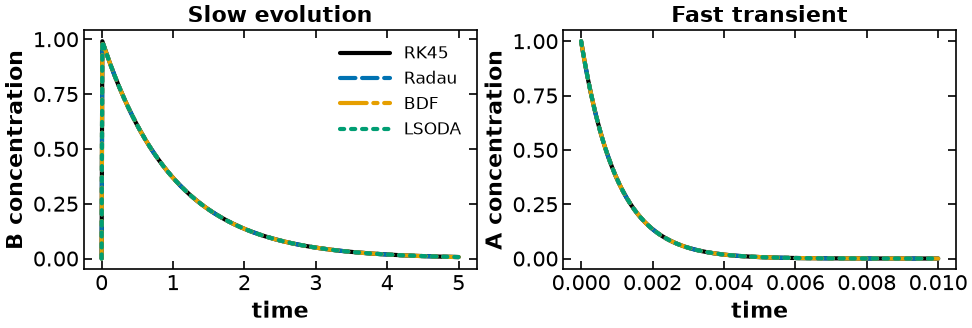

In [14]:
# A notebook-only diagnostic: do the four methods actually agree, on BOTH
# timescales? (Activity step 3 -- "check the important fast and slow
# behavior".) The handout figure is the tagged cell above; this one is here so
# you can look at the concentrations themselves.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
t_slow = np.linspace(0.0, t_final, 500)
t_fast = np.linspace(0.0, 0.01, 300)
for method, solution in solutions.items():
    axes[0].plot(t_slow, solution.sol(t_slow)[1], label=method)
    axes[1].plot(t_fast, solution.sol(t_fast)[0], label=method)
axes[0].set(xlabel="time", ylabel="B concentration", title="Slow evolution")
axes[1].set(xlabel="time", ylabel="A concentration", title="Fast transient")
axes[0].legend()
plt.tight_layout();

All four methods agree on the concentrations to better than $10^{-7}$, but they do **not** need comparable work. In the tested course environment (`scipy` 1.18, and identical on 1.7):

| method | kind | right-hand-side evaluations | accepted steps | LU factorizations | typical step after the transient |
| --- | --- | ---: | ---: | ---: | ---: |
| `RK45` | explicit | 11,012 | 1,582 | 0 | $3.3 \times 10^{-3}$ |
| `Radau` | implicit | 1,926 | 274 | 66 | $5.6 \times 10^{-2}$ |
| `BDF` | implicit | 556 | 277 | 52 | $7.9 \times 10^{-2}$ |
| `LSODA` | switching | 484 | 236 | 9 | $7.3 \times 10^{-2}$ |

The **mechanism** is in the left panel of the figure: once the fast transient is over, the solution is a smooth exponential decay and accuracy alone would permit a large step. `Radau`, `BDF` and `LSODA` take one. `RK45` cannot, because its step is capped by the *fast* eigenvalue $-k_1$ — still $-1000$ long after the mode it belongs to has died — at the Dormand--Prince stability limit $h \approx 3.3/k_1$. The step it actually takes, $3.25 \times 10^{-3}$, is that ceiling, not an accuracy requirement.

Exact counts depend on software version and tolerances; the qualitative gap — **roughly twenty times the work for the same answer** — is the lesson.

**Discussion:** Which method would you try first if this integration were repeated inside an optimization algorithm? What additional information would you check before deciding?